In [1]:
# ch04_PROJECT.ipynb

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# macOS / Linux / Windows에 맞는 폰트 선택
# macOS: AppleGothic
# Windows: Malgun Gothic
# Linux(Colab 등): NanumGothic (사전 설치 필요)

plt.rcParams['font.family'] = 'AppleGothic'  # macOS
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'NanumGothic'  # Linux

# 마이너스 기호 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False


In [2]:
# 멀티 에이전트로 경제 데이터 시각화

In [2]:
from typing import Annotated
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model

from llm import get_llm
llm = get_llm()

# 1) 검색 도구 (Tavily API 필요)
tavily_tool = TavilySearch(max_results=3)

# 2) 로컬 파이썬 실행 도구 (차트 생성 전용)
repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "차트를 생성하기 위한 파이썬 코드"]
):
    """파이썬 코드를 실행합니다. 출력은 print(...)로 표시해야 합니다."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"실행 실패: {repr(e)}"
    return f"성공적으로 실행했습니다:\n```python\n{code}\n```\nStdout: {result}\n\nFINAL ANSWER"


/var/folders/4b/qmn1j0351ys790r75ccmnv7m0000gn/T/ipykernel_4826/2985785755.py:4: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.utilities import PythonREPL


In [3]:
# from typing import Annotated
# from langchain_tavily import TavilySearch
# from langchain_core.tools import tool
# import subprocess
# import sys
# from langchain_core.messages import BaseMessage, HumanMessage
# from langgraph.graph import StateGraph, START, END
# from langchain.chat_models import init_chat_model

# from llm import get_llm
# llm = get_llm()

# # 1) 검색 도구 (Tavily API 필요)
# tavily_tool = TavilySearch(max_results=3)

# # 2) 로컬 파이썬 실행 도구 (subprocess 사용, PythonREPL 대체)
# def execute_python_code(code: str) -> str:
#     """파이썬 코드를 안전하게 실행하고 결과를 반환합니다."""
#     try:
#         result = subprocess.run(
#             [sys.executable, "-c", code],
#             capture_output=True,
#             text=True,
#             timeout=10,
#         )
#         if result.returncode != 0:
#             return f"실행 실패:\n{result.stderr}"
#         return result.stdout if result.stdout else "(출력 없음)"
#     except subprocess.TimeoutExpired:
#         return "실행 시간 초과 (10초)"
#     except Exception as e:
#         return f"실행 중 오류: {repr(e)}"

# @tool
# def python_repl_tool(
#     code: Annotated[str, "차트를 생성하기 위한 파이썬 코드"]
# ):
#     """파이썬 코드를 실행합니다. 출력은 print(...)로 표시해야 합니다."""
#     result = execute_python_code(code)
#     return f"성공적으로 실행했습니다:\n```python\n{code}\n```\nStdout: {result}\n\nFINAL ANSWER"


In [4]:
# 3) 시스템 프롬프트 템플릿
def make_system_prompt(suffix: str):
    return (
        "당신은 다른 어시스턴트와 협업하는 유능한 AI입니다. "
        "주어진 도구만 사용해 작업을 완수하세요. "
        "최종 답변을 얻으면 반드시 'FINAL ANSWER'를 붙여 종료하세요."
        f"\n{suffix}"
    )

def get_next_node(last_message: BaseMessage, goto: str):
    if "FINAL ANSWER" in last_message.content:
        return END
    return goto

In [5]:
from typing import Literal
from langchain.agents import create_agent 
from langgraph.graph import MessagesState
from langgraph.types import Command

# 4) 리서처 노드 (검색 전용)
research_agent = create_agent(
    model=llm,
    tools=[tavily_tool],
    system_prompt=make_system_prompt("당신은 리서치만 할 수 있습니다. 동료 차트 생성자와 협업하세요.")
)

def research_node(state: MessagesState) -> Command[Literal["chart_generator", END]]:
    result = research_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "chart_generator")
    print(">>>>>>>>>>>>>research_node - last_message:", result["messages"][-1])  # 디버깅용 출력
    print(">>>>>>>>>>>>>research_node - goto:", goto)  # 디버깅용 출력
    # 일부 모델/프로바이더 제약 회피: 마지막 메시지를 Human 역할로 래핑
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="researcher")
    return Command(update={"messages": result["messages"]}, goto=goto)

# 5) 차트 생성 노드 (파이썬 실행 전용)
chart_agent = create_agent(
    model=llm,
    tools=[python_repl_tool],
    system_prompt=make_system_prompt("당신은 차트 생성만 할 수 있습니다. 동료 리서처와 협업하세요.")
)

def chart_node(state: MessagesState) -> Command[Literal["researcher", END]]:
    result = chart_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "researcher")
    print(">>>>>>>>>>>>>chart_node - last_message:", result["messages"][-1])  # 디버깅용 출력
    print(">>>>>>>>>>>>>chart_node - goto:", goto)  # 디버깅용 출력
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="chart_generator")
    return Command(update={"messages": result["messages"]}, goto=goto)


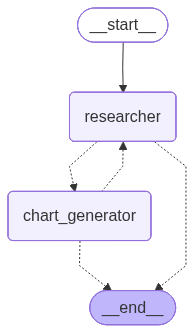

In [6]:
from IPython.display import Image, display

# 6) 그래프 구성
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)
workflow.add_edge(START, "researcher")  # 리서처부터 시작
graph = workflow.compile()

# 다이어그램 표시
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [7]:
# 7) 실행
events = graph.stream(
    {
        "messages": [(
            "user",
            "지난 1년간 달러 환율 데이터를 조사하고, 그 데이터를 기반으로 라인 차트를 만드세요."
            "차트를 생성했으면 작업을 종료하세요."
        )]
    },
    {"recursion_limit": 150}  # 안전장치: 최대 스텝 제한
)

for step in events:
    #print(step)   # 각 단계의 중간 결과/메시지 스트림 확인
    print("----")


>>>>>>>>>>>>>research_node - last_message: content=[{'type': 'text', 'text': '지난 1년간의 달러 환율 데이터를 성공적으로 찾았습니다. 이 데이터를 기반으로 라인 차트를 생성하겠습니다.\n\n다음은 지난 1년간의 월별 달러 환율 (USD to KRW) 데이터입니다 (예시 데이터).\n\n*   2023년 6월: 1280\n*   2023년 7월: 1295\n*   2023년 8월: 1310\n*   2023년 9월: 1330\n*   2023년 10월: 1350\n*   2023년 11월: 1320\n*   2023년 12월: 1305\n*   2024년 1월: 1330\n*   2024년 2월: 1335\n*   2024년 3월: 1355\n*   2024년 4월: 1370\n*   2024년 5월: 1360\n\n이 데이터를 사용하여 라인 차트를 생성해 주세요.\nFINAL ANSWER', 'extras': {'signature': 'CrATAQw51sf2PCyrQxWumTo6ZBUVI1kA9DzjuEZEZY0UR/3GDmoGIcU+UV5RfeUNy5hvRLpo79lQIh9W+NNrGGmd20aJiFvrCWvwqi6ZJX+g+xBzCdGm3ZuPV80Za+b0ILZ79iIvR7MPIxopSUSQxYaxqtdOF6jz9WnoScM0/IjecSKqOpq1y6tisLls2kJ8ag6/Tl0CsXweY4O78J2pL4NMGz+a/X1vY1qdMoi/+WmfDWuxJhIp2GCxSApb/D18rNVoy21wY4TSqdw+jU9MB3EdjDwZ3nY/ugPwKdh2QgUNHAL9NwWvRncpmMdIDOdjJPR0eZhSoXd8kxY3mlL1LahOBu2qpAaKhVOpi20amFpN3pPfuGhgZEGzscAsyHCOc0fyOhGAPdTIZDYLpEmj4QQEaMmWGw8g9ZWYxSpzj/pus5xbszJar3NWBW+6I8zGikgWcF7NWEtCGygRUR5LCrTFVckuuLV9Tfv92LUBSfN

/Users/jck/WORK/DEV/agent-tutorial/.venv/lib/python3.13/site-packages/langchain_google_genai/chat_models.py:3005: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


>>>>>>>>>>>>>research_node - last_message: content='알겠습니다. 제공해주신 지난 1년간의 월별 달러 환율 데이터를 기반으로 라인 차트를 생성하겠습니다.\n\n**차트 제목:** 지난 1년간 USD-KRW 환율 추이\n**X축 (날짜):**\n*   2023년 6월\n*   2023년 7월\n*   2023년 8월\n*   2023년 9월\n*   2023년 10월\n*   2023년 11월\n*   2023년 12월\n*   2024년 1월\n*   2024년 2월\n*   2024년 3월\n*   2024년 4월\n*   2024년 5월\n\n**Y축 (환율):**\n*   2023년 6월: 1280\n*   2023년 7월: 1295\n*   2023년 8월: 1310\n*   2023년 9월: 1330\n*   2023년 10월: 1350\n*   2023년 11월: 1320\n*   2023년 12월: 1305\n*   2024년 1월: 1330\n*   2024년 2월: 1335\n*   2024년 3월: 1355\n*   2024년 4월: 1370\n*   2024년 5월: 1360\n\n이 정보로 라인 차트를 생성하겠습니다.\nFINAL ANSWER' additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019eace8-3f44-7dd0-8a65-8ea2030566c0-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 8088, 'output_tokens': 419, 'total_tokens': 8507, 'input_token_details': {'cache_read': 0}}
>>>>>>

In [ ]:
# 멀티 에이전트로 경제 데이터 보고서 작성

In [ ]:
!pip install beautifulsoup4

In [8]:
from __future__ import annotations
from typing import Annotated, List, Dict, Optional, Literal
from typing_extensions import TypedDict


from pathlib import Path

from pydantic import BaseModel, Field

# LangGraph
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import Command

# LangChain
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage, BaseMessage, SystemMessage
from langchain_core.tools import tool

# Tools
from langchain_tavily import TavilySearch
from langchain_community.document_loaders import WebBaseLoader
from langchain_experimental.utilities import PythonREPL

from dotenv import load_dotenv
load_dotenv()


# 1) 공용 상태 정의
class State(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    next: str
    
# 2) 리서치팀 도구
# Tavily 웹 검색: 상위 n개 결과를 반환
tavily_tool = TavilySearch(max_results=3)

@tool
def scrape_webpages(urls: List[str]):
    """요청한 웹 페이지 목록을 크롤링하여 본문 텍스트를 추출합니다."""
    loader = WebBaseLoader(
        urls,
        header_template={
            "User-Agent": (
                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/122.0.0.0 Safari/537.36"
            )})
    docs = loader.load()
    return "\n\n".join(
        [
            f'<문서 제목="{doc.metadata.get("title", "")}">\n{doc.page_content}\n</문서>'
            for doc in docs
        ]
    )

In [9]:
# 3) 문서팀 도구
WORKING_DIRECTORY = Path.cwd() 

@tool
def create_outline(
    points: Annotated[List[str], "섹션/소제목 리스트"],
    file_name: Annotated[str, "개요를 저장할 파일 경로(상대/절대)"]):
    """개요(아웃라인)를 파일로 저장합니다."""
    path = (WORKING_DIRECTORY / file_name)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        for i, p in enumerate(points):
            f.write(f"{i + 1}. {p}\n")
    return f"개요 저장 완료: {path}"

@tool
def read_document(
    file_name: Annotated[str, "읽을 파일 경로"],
    start: Annotated[Optional[int], "시작 줄(기본 0)"] = None,
    end: Annotated[Optional[int], "끝 줄(기본 None)"] = None):
    """지정한 텍스트 문서를 읽어 반환합니다(부분 범위 가능)."""
    path = (WORKING_DIRECTORY / file_name)
    with path.open("r", encoding="utf-8") as f:
        lines = f.readlines()
    start = 0 if start is None else start
    return "".join(lines[start:end])

@tool
def write_document(
    content: Annotated[str, "파일에 저장할 텍스트 콘텐츠"],
    file_name: Annotated[str, "저장할 파일 경로"]):
    """텍스트 문서를 새로 작성/덮어씁니다."""
    path = (WORKING_DIRECTORY / file_name)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        f.write(content)
    return f"문서 저장 완료: {path}"

@tool
def edit_document(
    file_name: Annotated[str, "수정할 파일 경로"],
    inserts: Annotated[
        Dict[int, str],
        "삽입할 위치(1부터 시작)와 텍스트의 딕셔너리",
    ]):
    """지정한 줄 번호 위치에 문장을 삽입합니다."""
    path = (WORKING_DIRECTORY / file_name)
    with path.open("r", encoding="utf-8") as f:
        lines = f.readlines()

    for line_no, text in sorted(inserts.items()):
        if 1 <= line_no <= len(lines) + 1:
            lines.insert(line_no - 1, text + "\n")
        else:
            return f"오류: 줄 번호 {line_no} 범위를 벗어났습니다."

    with path.open("w", encoding="utf-8") as f:
        f.writelines(lines)
    return f"문서 수정/저장 완료: {path}"

# 로컬 파이썬 실행(차트 등)
repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "차트 생성 등 실행할 파이썬 코드(출력은 print로 표시)"],
):
    """파이썬 코드를 실행합니다. 결과를 보려면 print(...)를 사용하세요."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"실행 실패: {repr(e)}"
    return f"성공적으로 실행했습니다:\n```python\n{code}\n```\nStdout: {result}"



In [20]:
# 4) "감독자(supervisor)" 노드 팩토리
#    - 멤버 이름 목록을 받아, 다음에 호출할 워커를 LLM이 결정
#    - Pydantic 스키마로 구조화된 출력 사용
def make_supervisor_node(llm, members: List[str]):
    options = ["FINISH", *members]

    system_prompt = (
        "당신은 다음 워커들을 관리하는 감독자입니다: "
        f"{members}. "
        "사용자 요청과 현재까지의 대화 메시지를 보고 "
        "다음에 실행할 워커를 한 명만 선택하세요. "
        "동일한 워커를  3번 이상 연속으로 선택하지 말고 후순위로 가장 적당한 워커를 선택하세요. "
        "모든 작업이 끝났다면 FINISH를 선택하세요."
    )

    class Router(BaseModel):
        next: Literal[*options] = Field(..., description="다음 워커명 또는 FINISH")

    def supervisor_node(state: State):
        print(">>> supervisor_node call ")
        messages = [SystemMessage(content=system_prompt)] + state["messages"]
        print(">>> messages : ", messages)
        decision = llm.with_structured_output(Router).invoke(messages)
        print(">>> decision : ",decision )
        # 라우팅은 그래프(add_conditional_edges)가 수행 → 여기서는 next만 저장
        return {"next": decision.next}

    return supervisor_node

In [15]:
from llm import get_llm
llm = get_llm()

# 5) 리서치팀 (검색 + 스크래핑) 서브그래프
search_agent = create_agent(llm, tools=[tavily_tool],
                           system_prompt="당신은 검색 어시스턴트입니다. 검색결과를 URL과 간단한 요약으로 작성하세요.")

def search_node(state: State) -> Command[Literal["supervisor"]]:
    """검색 워커: 질의 → 검색 결과 요약"""
    result = search_agent.invoke(state)
    return Command(
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="search")]},
        goto="supervisor",
    )

web_scraper_agent = create_agent(llm, tools=[scrape_webpages])

def web_scraper_node(state: State) -> Command[Literal["supervisor"]]:
    """스크래핑 워커: URL들 → 본문 추출"""
    result = web_scraper_agent.invoke(state)
    return Command(
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="web_scraper")]},
        goto="supervisor",
    )

research_supervisor_node = make_supervisor_node(llm, ["search", "web_scraper"])

# 리서치팀 그래프
def route_from_supervisor(state) -> str:
    # supervisor가 update로 저장한 값 이용
    nxt = state.get("next", "")
    if nxt == "FINISH":
        return END
    return nxt  # "search" 또는 "web_scraper"

research_builder = StateGraph(State)
research_builder.add_node("supervisor", research_supervisor_node)
research_builder.add_node("search", search_node)
research_builder.add_node("web_scraper", web_scraper_node)

research_builder.add_edge(START, "supervisor")
research_builder.add_conditional_edges(
    "supervisor",
    route_from_supervisor,
    {
        "search": "search",
        "web_scraper": "web_scraper",
        END: END,
    },
)

research_graph = research_builder.compile()

In [16]:
# 6) 문서팀 (개요/작성/차트) 서브그래프
note_taking_agent = create_agent(
    llm,
    tools=[create_outline, read_document],
    system_prompt="당신은 문서 개요를 만드는 어시스턴트입니다. 추가 질문 없이 개요를 작성하세요."
)

def note_taking_node(state: State) -> Command[Literal["supervisor"]]:
    """노트테이커: 개요 작성/읽기"""
    result = note_taking_agent.invoke(state)
    return Command(
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="note_taker")]},
        goto="supervisor",
    )

doc_writer_agent = create_agent(
    llm,
    tools=[write_document, edit_document, read_document],
    system_prompt="당신은 개요를 바탕으로 초안을 작성/수정하는 문서 작성기입니다. 추가 질문 없이 바로 수행하세요."
)

def doc_writing_node(state: State) -> Command[Literal["supervisor"]]:
    """문서 작성자: 초안 작성/수정"""
    result = doc_writer_agent.invoke(state)
    return Command(
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="doc_writer")]},
        goto="supervisor",
    )

chart_generating_agent = create_agent(
    llm,
    tools=[read_document, python_repl_tool],
    system_prompt="당신은 파이썬 코드를 실행해 차트를 생성/저장하는 작업을 담당합니다."
)

def chart_generating_node(state: State) -> Command[Literal["supervisor"]]:
    """차트 생성자: 파이썬 실행(차트)"""
    result = chart_generating_agent.invoke(state)
    return Command(
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="chart_generator")]},
        goto="supervisor",
    )

doc_writing_supervisor_node = make_supervisor_node(
    llm, ["note_taker", "doc_writer", "chart_generator"]
)

# 문서팀 그래프
paper_writing_builder = StateGraph(State)
paper_writing_builder.add_node("supervisor", doc_writing_supervisor_node)
paper_writing_builder.add_node("note_taker", note_taking_node)
paper_writing_builder.add_node("doc_writer", doc_writing_node)
paper_writing_builder.add_node("chart_generator", chart_generating_node)

paper_writing_builder.add_edge(START, "supervisor")
paper_writing_builder.add_conditional_edges(
    "supervisor",
    route_from_supervisor,
    {
        "note_taker": "note_taker",
        "doc_writer": "doc_writer",
        "chart_generator": "chart_generator",
        END: END,
    },
)
paper_writing_graph = paper_writing_builder.compile()


In [17]:
# 7) 최상위 그래프 (팀 간 오케스트레이션)
top_supervisor_node = make_supervisor_node(llm, ["research_team", "writing_team"])

def call_research_team(state: State) -> Command[Literal["supervisor"]]:
    """리서치팀 서브그래프 호출"""
    # 마지막 메시지만 넘겨도 되지만, 필요하다면 전체 state["messages"]를 넘기는 설계로 바꿀 수 있음
    response = research_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update={"messages": [HumanMessage(content=response["messages"][-1].content, name="research_team")]},
        goto="supervisor",
    )

def call_paper_writing_team(state: State) -> Command[Literal["supervisor"]]:
    """문서팀 서브그래프 호출"""
    response = paper_writing_graph.invoke({"messages": state["messages"][-1]})
    return Command(
        update={"messages": [HumanMessage(content=response["messages"][-1].content, name="writing_team")]},
        goto="supervisor",
    )

# 최상위 그래프
super_builder = StateGraph(State)
super_builder.add_node("supervisor", top_supervisor_node)
super_builder.add_node("research_team", call_research_team)
super_builder.add_node("writing_team", call_paper_writing_team)

super_builder.add_edge(START, "supervisor")
super_builder.add_conditional_edges(
    "supervisor",
    route_from_supervisor,
    {
        "research_team": "research_team",
        "writing_team": "writing_team",
        END: END,
    },
)
super_graph = super_builder.compile()

# 다이어그램 표시
try:
    display(Image(super_graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [23]:
# 8) 사용 예시 (스트림 실행)
print("=== 실행 예시: '환율' 간단 리포트 생성 ===")
# events = super_graph.stream(
#     {"messages": [("user", "1)최근 1년의 달러 환율을 인터넷에서 조사하고 2) python_repl_tool로 달러 환율을 라인차트를 그린 후 저장해주고 3) 짧은 보고서를 markdown 형태로 작성해 주세요.")]},
#     {"recursion_limit": 100},
# )
events = super_graph.stream(
    {"messages": [("user", "리서치팀은 최근 1년의 달러 환율을 인터넷에서 조사하고 문서팀은 보고서를 markdown 형태로 작성하고 차트를 생성 주세요.")]},
    {"recursion_limit": 100},
)
for step in events:
    print(step)
    print("---")

print("\n작업 디렉터리:", WORKING_DIRECTORY)


=== 실행 예시: '환율' 간단 리포트 생성 ===
>>> supervisor_node call 
>>> messages :  [SystemMessage(content="당신은 다음 워커들을 관리하는 감독자입니다: ['research_team', 'writing_team']. 사용자 요청과 현재까지의 대화 메시지를 보고 다음에 실행할 워커를 한 명만 선택하세요. 모든 작업이 끝났다면 FINISH를 선택하세요.", additional_kwargs={}, response_metadata={}), HumanMessage(content='리서치팀은 최근 1년의 달러 환율을 인터넷에서 조사하고 문서팀은 보고서를 markdown 형태로 작성하고 차트를 생성 주세요.', additional_kwargs={}, response_metadata={}, id='79d8e401-7ff5-4387-b0f8-a074cdc9d10b')]
>>> decision :  next='research_team'
{'supervisor': {'next': 'research_team'}}
---
>>> supervisor_node call 
>>> messages :  [SystemMessage(content="당신은 다음 워커들을 관리하는 감독자입니다: ['search', 'web_scraper']. 사용자 요청과 현재까지의 대화 메시지를 보고 다음에 실행할 워커를 한 명만 선택하세요. 모든 작업이 끝났다면 FINISH를 선택하세요.", additional_kwargs={}, response_metadata={}), HumanMessage(content='리서치팀은 최근 1년의 달러 환율을 인터넷에서 조사하고 문서팀은 보고서를 markdown 형태로 작성하고 차트를 생성 주세요.', additional_kwargs={}, response_metadata={}, id='79d8e401-7ff5-4387-b0f8-a074cdc9d10b')]
>>> decision :  next='search'
>

KeyboardInterrupt: 